In [1]:
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cpu


In [2]:
DATA_PATH = "data_curated.csv"

# Leave as None for automatic detection.
SMILES_COLUMN = None
TARGET_COLUMN = None

BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

HIDDEN_DIM = 64
DROPOUT = 0.20

TEST_SIZE = 0.15
VALID_SIZE = 0.15

MODEL_PATH = "mlp_solubility.pt"

In [3]:
def load_table(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {path.resolve()}"
        )

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)

    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)

    raise ValueError("Supported formats: CSV, XLSX, XLS")


df = load_table(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (9982, 26)


,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Occurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934



Columns:
['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD', 'Occurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT']


In [4]:
def find_column(columns, candidates):
    lower_map = {
        str(c).strip().lower(): c
        for c in columns
    }

    # Exact match first
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    # Partial match second
    for c in columns:
        c_low = str(c).strip().lower()

        for candidate in candidates:
            if candidate.lower() in c_low:
                return c

    return None


if SMILES_COLUMN is None:
    SMILES_COLUMN = find_column(
        df.columns,
        [
            "smiles",
            "canonical smiles",
            "isomeric smiles",
            "canonical_smiles"
        ]
    )


if TARGET_COLUMN is None:
    TARGET_COLUMN = find_column(
        df.columns,
        [
            "logs",
            "log s",
            "logs (mol/l)",
            "log solubility",
            "solubility",
            "logS"
        ]
    )


print("SMILES column:", SMILES_COLUMN)
print("Target column:", TARGET_COLUMN)


if SMILES_COLUMN is None or TARGET_COLUMN is None:
    raise ValueError(
        "Could not automatically identify the columns. "
        "Set SMILES_COLUMN and TARGET_COLUMN manually."
    )

SMILES column: SMILES
Target column: Solubility


In [5]:
work_df = df[
    [SMILES_COLUMN, TARGET_COLUMN]
].copy()

work_df.columns = [
    "SMILES",
    "target"
]

work_df["SMILES"] = (
    work_df["SMILES"]
    .astype(str)
    .str.strip()
)

work_df["target"] = pd.to_numeric(
    work_df["target"],
    errors="coerce"
)

work_df = work_df.dropna(
    subset=["SMILES", "target"]
).copy()


def valid_smiles(smiles):
    return Chem.MolFromSmiles(smiles) is not None


valid_mask = work_df["SMILES"].apply(valid_smiles)

print(
    "Invalid SMILES removed:",
    int((~valid_mask).sum())
)

work_df = work_df[valid_mask].copy()

work_df = (
    work_df
    .drop_duplicates(subset=["SMILES"])
    .reset_index(drop=True)
)

print("Final dataset:", work_df.shape)

display(work_df.head())

[12:15:56] WARNING: not removing hydrogen atom without neighbors
[12:15:56] WARNING: not removing hydrogen atom without neighbors
[12:15:56] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not removing hydrogen atom without neighbors
[12:15:57] WARNING: not r

Invalid SMILES removed: 2
Final dataset: (9980, 2)


,SMILES,target
0,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127
1,O=C1Nc2cccc3cccc1c23,-3.254767
2,Clc1ccc(C=O)cc1,-2.177078
3,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409
4,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065


In [6]:
indices = np.arange(len(work_df))

train_valid_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED
)

valid_fraction = VALID_SIZE / (1.0 - TEST_SIZE)

train_idx, valid_idx = train_test_split(
    train_valid_idx,
    test_size=valid_fraction,
    random_state=SEED
)

train_df = work_df.iloc[
    train_idx
].reset_index(drop=True)

valid_df = work_df.iloc[
    valid_idx
].reset_index(drop=True)

test_df = work_df.iloc[
    test_idx
].reset_index(drop=True)


print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))

Train: 6986
Valid: 1497
Test : 1497


In [7]:
DESCRIPTOR_NAMES = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "MolMR",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "NumRings",
    "NumAromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
    "NumAliphaticRings",
    "NumSaturatedRings",
    "NumHeteroatoms",
]


def calculate_descriptors(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(
            f"Invalid SMILES: {smiles}"
        )

    values = [

        Descriptors.MolWt(mol),

        Crippen.MolLogP(mol),

        rdMolDescriptors.CalcTPSA(mol),

        Crippen.MolMR(mol),

        Lipinski.NumHDonors(mol),

        Lipinski.NumHAcceptors(mol),

        Lipinski.NumRotatableBonds(mol),

        Lipinski.RingCount(mol),

        Lipinski.NumAromaticRings(mol),

        rdMolDescriptors.CalcFractionCSP3(mol),

        Lipinski.HeavyAtomCount(mol),

        rdMolDescriptors.CalcNumAliphaticRings(mol),

        rdMolDescriptors.CalcNumSaturatedRings(mol),

        rdMolDescriptors.CalcNumHeteroatoms(mol)
    ]

    return np.asarray(
        values,
        dtype=np.float32
    )


DESCRIPTOR_DIM = len(DESCRIPTOR_NAMES)

print(
    "Number of descriptors:",
    DESCRIPTOR_DIM
)

for i, name in enumerate(DESCRIPTOR_NAMES):
    print(i, name)

Number of descriptors: 14
0 MolWt
1 MolLogP
2 TPSA
3 MolMR
4 NumHDonors
5 NumHAcceptors
6 NumRotatableBonds
7 NumRings
8 NumAromaticRings
9 FractionCSP3
10 HeavyAtomCount
11 NumAliphaticRings
12 NumSaturatedRings
13 NumHeteroatoms


In [8]:
def make_descriptor_matrix(frame):

    return np.vstack([
        calculate_descriptors(smiles)
        for smiles in frame["SMILES"]
    ]).astype(np.float32)


X_train = make_descriptor_matrix(train_df)
X_valid = make_descriptor_matrix(valid_df)
X_test = make_descriptor_matrix(test_df)

y_train = train_df["target"].values.astype(np.float32)
y_valid = valid_df["target"].values.astype(np.float32)
y_test = test_df["target"].values.astype(np.float32)


print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)
print("y_test :", y_test.shape)

[12:15:59] WARNING: not removing hydrogen atom without neighbors
[12:15:59] WARNING: not removing hydrogen atom without neighbors
[12:16:00] WARNING: not removing hydrogen atom without neighbors
[12:16:00] WARNING: not removing hydrogen atom without neighbors
[12:16:00] WARNING: not removing hydrogen atom without neighbors
[12:16:01] WARNING: not removing hydrogen atom without neighbors
[12:16:02] WARNING: not removing hydrogen atom without neighbors
[12:16:02] WARNING: not removing hydrogen atom without neighbors
[12:16:02] WARNING: not removing hydrogen atom without neighbors
[12:16:03] WARNING: not removing hydrogen atom without neighbors
[12:16:03] WARNING: not removing hydrogen atom without neighbors
[12:16:03] WARNING: not removing hydrogen atom without neighbors
[12:16:03] WARNING: not removing hydrogen atom without neighbors
[12:16:04] WARNING: not removing hydrogen atom without neighbors
[12:16:04] WARNING: not removing hydrogen atom without neighbors
[12:16:04] WARNING: not r

X_train: (6986, 14)
X_valid: (1497, 14)
X_test : (1497, 14)
y_train: (6986,)
y_valid: (1497,)
y_test : (1497,)


[12:16:14] WARNING: not removing hydrogen atom without neighbors
[12:16:14] WARNING: not removing hydrogen atom without neighbors


In [9]:
descriptor_df = pd.DataFrame(
    X_train,
    columns=DESCRIPTOR_NAMES
)

display(descriptor_df.head())
display(descriptor_df.describe().T)

,MolWt,MolLogP,TPSA,MolMR,NumHDonors,NumHAcceptors,NumRotatableBonds,NumRings,NumAromaticRings,FractionCSP3,HeavyAtomCount,NumAliphaticRings,NumSaturatedRings,NumHeteroatoms
0,458.609985,3.16520,114.400002,117.692200,0.0,10.0,7.0,2.0,2.0,0.555556,30.0,0.0,0.0,12.0
1,267.330994,5.62750,15.790000,90.816704,1.0,0.0,0.0,5.0,5.0,0.000000,21.0,0.0,0.0,1.0
2,354.487000,3.04290,97.989998,98.143204,4.0,4.0,12.0,1.0,0.0,0.750000,25.0,1.0,1.0,5.0
3,940.255981,-6.84770,319.600006,195.405304,2.0,21.0,15.0,5.0,4.0,0.166667,59.0,1.0,0.0,29.0
4,164.207993,1.50992,46.330002,49.165401,1.0,1.0,1.0,1.0,1.0,0.222222,12.0,0.0,0.0,3.0


,count,mean,std,min,25%,50%,75%,max
MolWt,6986.0,267.275391,179.579041,9.012000,162.151993,229.312500,321.375252,2967.980957
MolLogP,6986.0,1.976906,3.524772,-40.873199,0.606010,1.949100,3.436515,68.541138
TPSA,6986.0,62.776466,63.458061,0.000000,26.299999,51.680000,80.260002,1017.840027
MolMR,6986.0,66.812935,45.154747,0.000000,40.463224,58.845900,82.255377,850.646973
NumHDonors,6986.0,1.105210,1.472228,0.000000,0.000000,1.000000,2.000000,26.000000
NumHAcceptors,6986.0,3.413398,3.355443,0.000000,2.000000,3.000000,4.000000,54.000000
NumRotatableBonds,6986.0,4.078013,5.638558,0.000000,1.000000,3.000000,5.000000,141.000000
NumRings,6986.0,1.521615,1.598641,0.000000,0.000000,1.000000,2.000000,22.000000
NumAromaticRings,6986.0,1.060407,1.258472,0.000000,0.000000,1.000000,2.000000,16.000000
FractionCSP3,6986.0,0.427469,0.354899,0.000000,0.100000,0.363636,0.750000,1.000000


In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
).astype(np.float32)

X_valid = scaler.transform(
    X_valid
).astype(np.float32)

X_test = scaler.transform(
    X_test
).astype(np.float32)


print(
    "Training feature means:",
    np.round(X_train.mean(axis=0), 3)
)

print(
    "Training feature std:",
    np.round(X_train.std(axis=0), 3)
)

Training feature means: [ 0. -0. -0. -0. -0.  0. -0.  0.  0.  0.  0. -0.  0.  0.]
Training feature std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [11]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(y_train)
)

valid_dataset = TensorDataset(
    torch.tensor(X_valid),
    torch.tensor(y_valid)
)

test_dataset = TensorDataset(
    torch.tensor(X_test),
    torch.tensor(y_test)
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [12]:
class PureMLP(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        dropout=0.2
    ):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim,
                1
            )
        )

    def forward(self, x):

        return self.network(x).view(-1)


model = PureMLP(
    input_dim=DESCRIPTOR_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
).to(DEVICE)


print(model)

print(
    "\nTrainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

PureMLP(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 5185


In [13]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [14]:
@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    for X, y in loader:

        X = X.to(DEVICE)
        y = y.to(DEVICE)

        prediction = model(X)

        y_true.extend(
            y.cpu().numpy()
        )

        y_pred.extend(
            prediction.cpu().numpy()
        )

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [15]:
history = {
    "train_loss": [],
    "valid_mse": []
}

best_valid_mse = float("inf")
best_epoch = -1


for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()

    running_loss = 0.0
    n_samples = 0


    for X, y in train_loader:

        X = X.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = model(X)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()


        batch_size = y.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        n_samples += batch_size


    train_loss = (
        running_loss
        / n_samples
    )


    valid_metrics = evaluate(
        model,
        valid_loader
    )

    valid_mse = valid_metrics["MSE"]


    history["train_loss"].append(
        train_loss
    )

    history["valid_mse"].append(
        valid_mse
    )


    if valid_mse < best_valid_mse:

        best_valid_mse = valid_mse

        best_epoch = epoch

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )


    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Epoch {epoch:3d} | "
            f"Train MSE: {train_loss:.4f} | "
            f"Valid MSE: {valid_mse:.4f}"
        )


print("\nBest epoch:", best_epoch)

print(
    "Best validation MSE:",
    best_valid_mse
)

Epoch   1 | Train MSE: 5.1271 | Valid MSE: 2.8885
Epoch  10 | Train MSE: 2.0892 | Valid MSE: 1.6159
Epoch  20 | Train MSE: 1.8889 | Valid MSE: 1.4761
Epoch  30 | Train MSE: 1.7251 | Valid MSE: 1.4049
Epoch  40 | Train MSE: 1.6316 | Valid MSE: 1.3283
Epoch  50 | Train MSE: 1.6029 | Valid MSE: 1.3793
Epoch  60 | Train MSE: 1.5292 | Valid MSE: 1.2862
Epoch  70 | Train MSE: 1.4827 | Valid MSE: 1.2967
Epoch  80 | Train MSE: 1.4775 | Valid MSE: 1.2902
Epoch  90 | Train MSE: 1.4517 | Valid MSE: 1.2758
Epoch 100 | Train MSE: 1.4496 | Valid MSE: 1.2803
Epoch 110 | Train MSE: 1.4383 | Valid MSE: 1.2977
Epoch 120 | Train MSE: 1.4134 | Valid MSE: 1.2568
Epoch 130 | Train MSE: 1.4494 | Valid MSE: 1.2267
Epoch 140 | Train MSE: 1.3235 | Valid MSE: 1.2553
Epoch 150 | Train MSE: 1.3488 | Valid MSE: 1.2339
Epoch 160 | Train MSE: 1.3453 | Valid MSE: 1.2556
Epoch 170 | Train MSE: 1.3465 | Valid MSE: 1.2183
Epoch 180 | Train MSE: 1.3300 | Valid MSE: 1.2635
Epoch 190 | Train MSE: 1.3348 | Valid MSE: 1.3084


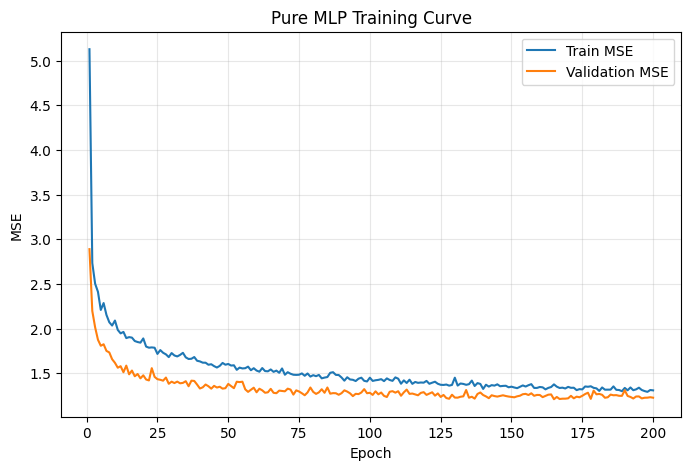

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    history["train_loss"],
    label="Train MSE"
)

plt.plot(
    range(1, EPOCHS + 1),
    history["valid_mse"],
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Pure MLP Training Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [17]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print(
    "Loaded best model from epoch:",
    best_epoch
)

Loaded best model from epoch: 165


In [18]:
test_metrics = evaluate(
    model,
    test_loader
)

print(
    f"Test MSE : "
    f"{test_metrics['MSE']:.4f}"
)

print(
    f"Test RMSE: "
    f"{test_metrics['RMSE']:.4f}"
)

print(
    f"Test MAE : "
    f"{test_metrics['MAE']:.4f}"
)

print(
    f"Test R²  : "
    f"{test_metrics['R2']:.4f}"
)

Test MSE : 1.1515
Test RMSE: 1.0731
Test MAE : 0.7693
Test R²  : 0.7890


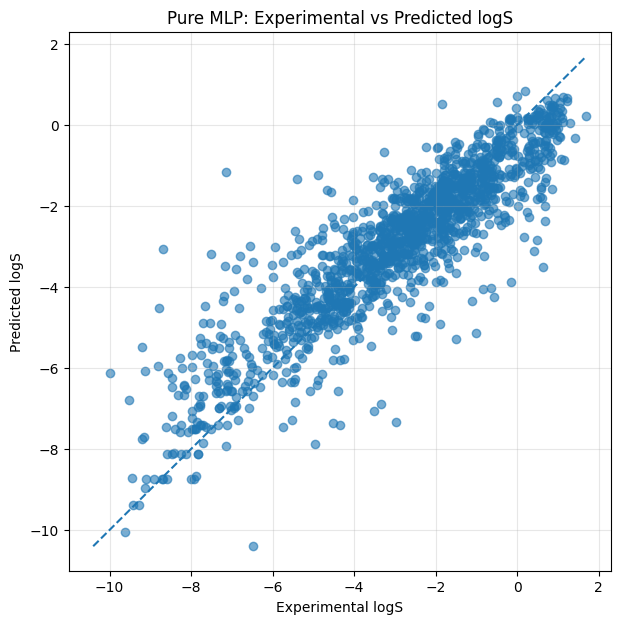

In [19]:
y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.6
)

min_value = min(
    y_true.min(),
    y_pred.min()
)

max_value = max(
    y_true.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Experimental logS")
plt.ylabel("Predicted logS")

plt.title(
    "Pure MLP: Experimental vs Predicted logS"
)

plt.grid(alpha=0.3)

plt.show()